In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('../data/Online Retail.xlsx')

# Basic check
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDate range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


 "25% of transactions are untracked guest purchases, limiting retention analysis."

In [3]:
# Remove rows with no CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# Remove cancellations (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative/zero quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Add revenue column
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Convert CustomerID to int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print("Clean shape:", df_clean.shape)
print("Unique customers:", df_clean['CustomerID'].nunique())
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Clean shape: (397884, 9)
Unique customers: 4338
Rows removed: 144025


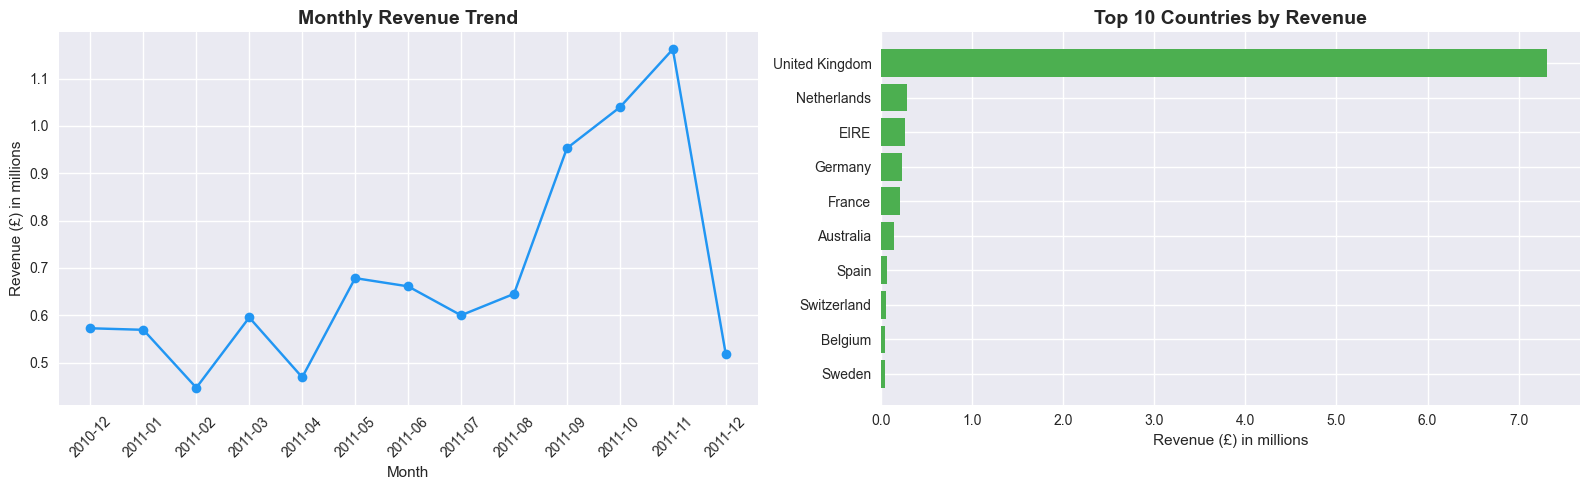

Total Revenue: £8,911,408
Average Order Value: £480.87
Top country: United Kingdom (82.0% of revenue)


In [13]:
# Set plot style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Chart 1: Monthly Revenue Trend ---
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('Month')['Revenue'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

axes[0].plot(monthly_revenue['Month'], monthly_revenue['Revenue'], marker='o', color='#2196F3')
axes[0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (£) in millions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

# --- Chart 2: Top 10 Countries by Revenue ---
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#4CAF50')
axes[1].set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue (£) in millions')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

plt.tight_layout()
plt.savefig('../data/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

# Key stats
print("Total Revenue: £{:,.0f}".format(df_clean['Revenue'].sum()))
print("Average Order Value: £{:,.2f}".format(df_clean.groupby('InvoiceNo')['Revenue'].sum().mean()))
print("Top country:", top_countries.index[0], "({:.1f}% of revenue)".format(top_countries.values[0]/df_clean['Revenue'].sum()*100))

In [14]:
import datetime as dt

# Set reference date as day after last transaction
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Build RFM table
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(rfm.describe().round(2))

       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.54       4.27    2054.27
std       1721.81   100.01       7.70    8989.23
min      12346.00     1.00       1.00       3.75
25%      13813.25    18.00       1.00     307.41
50%      15299.50    51.00       2.00     674.48
75%      16778.75   142.00       5.00    1661.74
max      18287.00   374.00     209.00  280206.02


In [15]:
# Score each metric 1-5 using quintiles
# Recency: lower is better, so reverse the labels
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# Combine into overall RFM score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Segment customers based on score
def segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal'
    elif score >= 7:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

# Summary table
segment_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(1)

segment_summary['% of Customers'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() * 100).round(1)
segment_summary['% of Revenue'] = (segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100).round(1)

print(segment_summary)

           Customers  Avg_Recency  Avg_Frequency  Total_Revenue  \
Segment                                                           
At Risk         1092         85.4            2.0       882612.7   
Champions        934         14.6           11.7      6255336.5   
Lost            1304        192.3            1.1       364828.8   
Loyal           1008         43.4            3.9      1408629.9   

           % of Customers  % of Revenue  
Segment                                  
At Risk              25.2           9.9  
Champions            21.5          70.2  
Lost                 30.1           4.1  
Loyal                23.2          15.8  


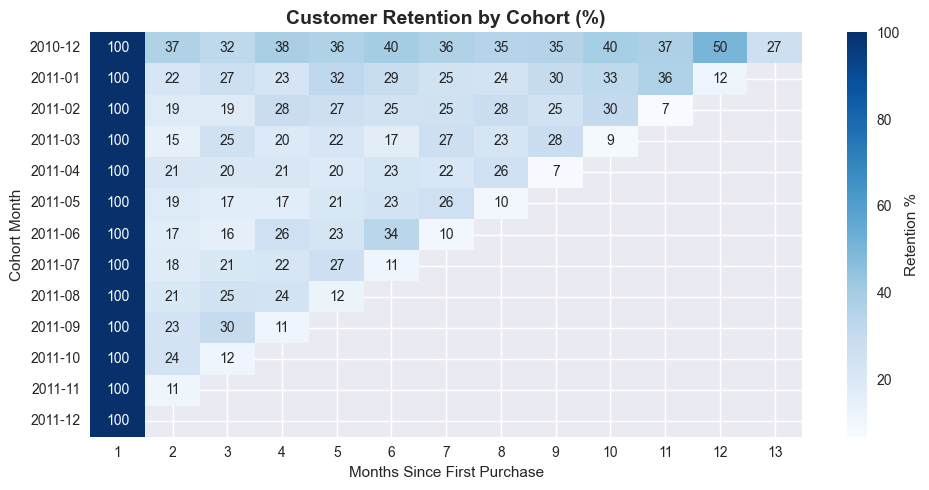


Month 1 retention average: 20.6 %


In [18]:
# Assign each customer's cohort = month of first purchase
df_clean['OrderMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Calculate cohort index (months since first purchase)
def get_month_diff(df, col1, col2):
    year_diff = df[col1].dt.year - df[col2].dt.year
    month_diff = df[col1].dt.month - df[col2].dt.month
    return year_diff * 12 + month_diff + 1

df_clean['CohortIndex'] = get_month_diff(df_clean, 'OrderMonth', 'CohortMonth')

# Build cohort table
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Convert to retention %
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label': 'Retention %'})
plt.title('Customer Retention by Cohort (%)', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('../data/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMonth 1 retention average:", retention[2].mean().round(1), "%")

## Key Findings

1. **Revenue concentration**: 21.5% of customers (Champions segment) generate 70.2% of total revenue (£6.26M), while 55% of customers (At Risk + Lost) contribute only 14%.

2. **Retention cliff**: Month-1 retention averages ~22% across cohorts — the majority of customers churn after their first purchase, identifying onboarding as the highest-leverage intervention point.

3. **Loyalty correlation**: The December 2010 cohort shows notably higher long-term retention (35-40%) than later cohorts, suggesting early customer experience or promotional terms may have driven stronger loyalty.

## Recommendations

- Launch a post-first-purchase email sequence targeting Month-1 retention
- Build a loyalty programme for the 934 "Champions" customers driving 70% of revenue
- Re-engagement campaign for the 1,092 "At Risk" customers before they become "Lost"